In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from shapely.geometry import shape
import json

In [2]:
# 1. Load the geojson file manually (to avoid potential library version conflicts)
with open('/Users/linaruiz/Documents/STEPT1D/data/shapes.geojson', 'r') as f:
    data = json.load(f)

features = []
for feature in data['features']:
    properties = feature['properties']
    geometry = shape(feature['geometry'])
    features.append({**properties, 'geometry': geometry})

gdf = gpd.GeoDataFrame(features)

In [3]:
gdf.columns

Index(['geo_point_2d', 'area', 'perimeter', 'dpto', 'nombre_dpt', 'mpio',
       'nombre_mpi', 'nombre_cab', 'mpios', 'hectares', 'geometry'],
      dtype='object')

In [4]:
gdf["geometry"]

0       POLYGON ((-77.2136 7.9005, -77.1825 7.8859, -7...
1       POLYGON ((-75.32752 7.92516, -75.3217 7.9318, ...
2       POLYGON ((-75.21455 8.03189, -75.2019 8.0318, ...
3       POLYGON ((-76.4067 8.0831, -76.413 8.0733, -76...
4       POLYGON ((-72.5023 7.8715, -72.4919 7.868, -72...
                              ...                        
1117    POLYGON ((-74.69577 10.22744, -74.69933 10.226...
1118    POLYGON ((-74.70518 10.27644, -74.69872 10.263...
1119    POLYGON ((-74.6766 5.7584, -74.6754 5.7463, -7...
1120    POLYGON ((-76.89271 7.24821, -76.89113 7.22927...
1121    POLYGON ((-81.37021 13.38584, -81.37021 13.385...
Name: geometry, Length: 1122, dtype: geometry

In [5]:
features

[{'geo_point_2d': {'lon': -77.34626852235178, 'lat': 7.374159188574821},
  'area': 6098643088.48,
  'perimeter': 488610.332913,
  'dpto': '27',
  'nombre_dpt': 'CHOCO',
  'mpio': '615',
  'nombre_mpi': 'RIOSUCIO',
  'nombre_cab': 'RIOSUCIO',
  'mpios': '27615',
  'hectares': 609864.309,
  'geometry': <POLYGON ((-77.214 7.9, -77.183 7.886, -77.17 7.886, -77.155 7.886, -77.136 ...>},
 {'geo_point_2d': {'lon': -75.23403347240121, 'lat': 7.6666705013497065},
  'area': 2035307370.16,
  'perimeter': 215948.20888,
  'dpto': '05',
  'nombre_dpt': 'ANTIOQUIA',
  'mpio': '120',
  'nombre_mpi': 'CACERES',
  'nombre_cab': 'CACERES',
  'mpios': '05120',
  'hectares': 203530.737,
  'geometry': <POLYGON ((-75.328 7.925, -75.322 7.932, -75.309 7.932, -75.301 7.933, -75.2...>},
 {'geo_point_2d': {'lon': -75.01348689658747, 'lat': 7.842802571586887},
  'area': 1320915901.88,
  'perimeter': 192458.577308,
  'dpto': '05',
  'nombre_dpt': 'ANTIOQUIA',
  'mpio': '154',
  'nombre_mpi': 'CAUCASIA',
  'nombre_

In [6]:
data['features'][0]['geometry']

{'coordinates': [[[-77.21360015870256, 7.900499820708228],
   [-77.182502746593, 7.885900020598448],
   [-77.17040252686637, 7.88640022277743],
   [-77.15480041504986, 7.88579988479529],
   [-77.13639831544037, 7.885700225829269],
   [-77.1288986206161, 7.883399963378112],
   [-77.10990142823314, 7.876399993895734],
   [-77.09950256348696, 7.864200115203127],
   [-77.09950256348695, 7.857299804686772],
   [-77.1087036132917, 7.848599910735336],
   [-77.11560058594797, 7.834199905394748],
   [-77.12539672852617, 7.831399917601762],
   [-77.13639831544032, 7.834899902342944],
   [-77.149002075206, 7.822199821471336],
   [-77.13289642335039, 7.795000076293153],
   [-77.11499786377993, 7.766600131987773],
   [-77.10169982911184, 7.740600109099621],
   [-77.08850097657267, 7.729000091552041],
   [-77.06770324708033, 7.714499950408282],
   [-77.03829956055665, 7.690700054168103],
   [-77.02100372315417, 7.6767001152032925],
   [-77.00164031983368, 7.657863616942827],
   [-76.9837646484468, 7

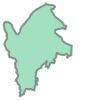

In [7]:
shape(data['features'][0]['geometry'])

In [8]:
data['features'][0]['properties']

{'geo_point_2d': {'lon': -77.34626852235178, 'lat': 7.374159188574821},
 'area': 6098643088.48,
 'perimeter': 488610.332913,
 'dpto': '27',
 'nombre_dpt': 'CHOCO',
 'mpio': '615',
 'nombre_mpi': 'RIOSUCIO',
 'nombre_cab': 'RIOSUCIO',
 'mpios': '27615',
 'hectares': 609864.309}

In [9]:
# 2. Define the municipalities of Valle de Aburrá 
# (Note: Names in the dataset are in uppercase and without accents)
vda_names = [
    'BARBOSA', 'GIRARDOTA', 'COPACABANA', 'BELLO', 'MEDELLIN', 
    'ITAGUI', 'SABANETA', 'LA ESTRELLA', 'CALDAS', 'ENVIGADO'
]

In [10]:
# 3. Filter and Dissolve
# Dissolve merges multiple polygons for the same municipality into one
vda_gdf = gdf[(gdf['nombre_mpi'].isin(vda_names)) & (gdf['nombre_dpt'] == 'ANTIOQUIA')]

In [11]:
vda_gdf

,geo_point_2d,area,perimeter,dpto,nombre_dpt,mpio,nombre_mpi,nombre_cab,mpios,hectares,geometry
40,"{'lon': -75.66639719011212, 'lat': 6.140715295...",3.707592e+07,26842.088949,05,ANTIOQUIA,380,LA ESTRELLA,LA ESTRELLA,05380,3707.592,"POLYGON ((-75.6943 6.1711, -75.6908 6.1745, -7..."
50,"{'lon': -75.4623075962768, 'lat': 6.3678922557...",8.273771e+07,37254.629252,05,ANTIOQUIA,308,GIRARDOTA,GIRARDOTA,05308,8273.771,"POLYGON ((-75.4938 6.4215, -75.4823 6.4203, -7..."
159,"{'lon': -75.6311671548033, 'lat': 6.1787410294...",2.349791e+07,21863.723908,05,ANTIOQUIA,360,ITAGUI,ITAGUI,05360,2349.791,"POLYGON ((-75.5911 6.1862, -75.5951 6.1793, -7..."
713,"{'lon': -75.58709654452825, 'lat': 6.145351954...",4.681151e+07,28567.419315,05,ANTIOQUIA,266,ENVIGADO,ENVIGADO,05266,4681.151,"POLYGON ((-75.5911 6.1862, -75.5859 6.1851, -7..."
714,"{'lon': -75.62737296351378, 'lat': 6.128914753...",2.157092e+07,19196.288692,05,ANTIOQUIA,631,SABANETA,SABANETA,05631,2157.092,"POLYGON ((-75.6407 6.1524, -75.6228 6.1621, -7..."
720,"{'lon': -75.60205263042899, 'lat': 6.356132892...",1.505025e+08,50813.389570,05,ANTIOQUIA,088,BELLO,BELLO,05088,15050.245,"POLYGON ((-75.6765 6.4072, -75.6679 6.4061, -7..."
721,"{'lon': -75.5186577548687, 'lat': 6.3521780206...",6.631060e+07,37701.402725,05,ANTIOQUIA,212,COPACABANA,COPACABANA,05212,6631.060,"POLYGON ((-75.5503 6.3963, -75.5457 6.4003, -7..."
726,"{'lon': -75.63908382612378, 'lat': 6.039077571...",1.527902e+08,53659.442286,05,ANTIOQUIA,129,CALDAS,CALDAS,05129,15279.021,"POLYGON ((-75.6856 6.1173, -75.6798 6.115, -75..."
915,"{'lon': -75.63644852366333, 'lat': 6.265185549...",3.616566e+08,98913.695353,05,ANTIOQUIA,001,MEDELLIN,MEDELLIN,05001,36165.657,"POLYGON ((-75.6754 6.3812, -75.6754 6.3749, -7..."
1083,"{'lon': -75.34325329829018, 'lat': 6.430761901...",2.214853e+08,65488.906726,05,ANTIOQUIA,079,BARBOSA,BARBOSA,05079,22148.527,"POLYGON ((-75.2616 6.5072, -75.2592 6.502, -75..."


In [12]:
# 4. Create Dummy Magnitude Data
np.random.seed(42)
vda_gdf['magnitude'] = np.random.randint(10, 100, size=len(vda_gdf))

/Users/linaruiz/Documents/STEPT1D/venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


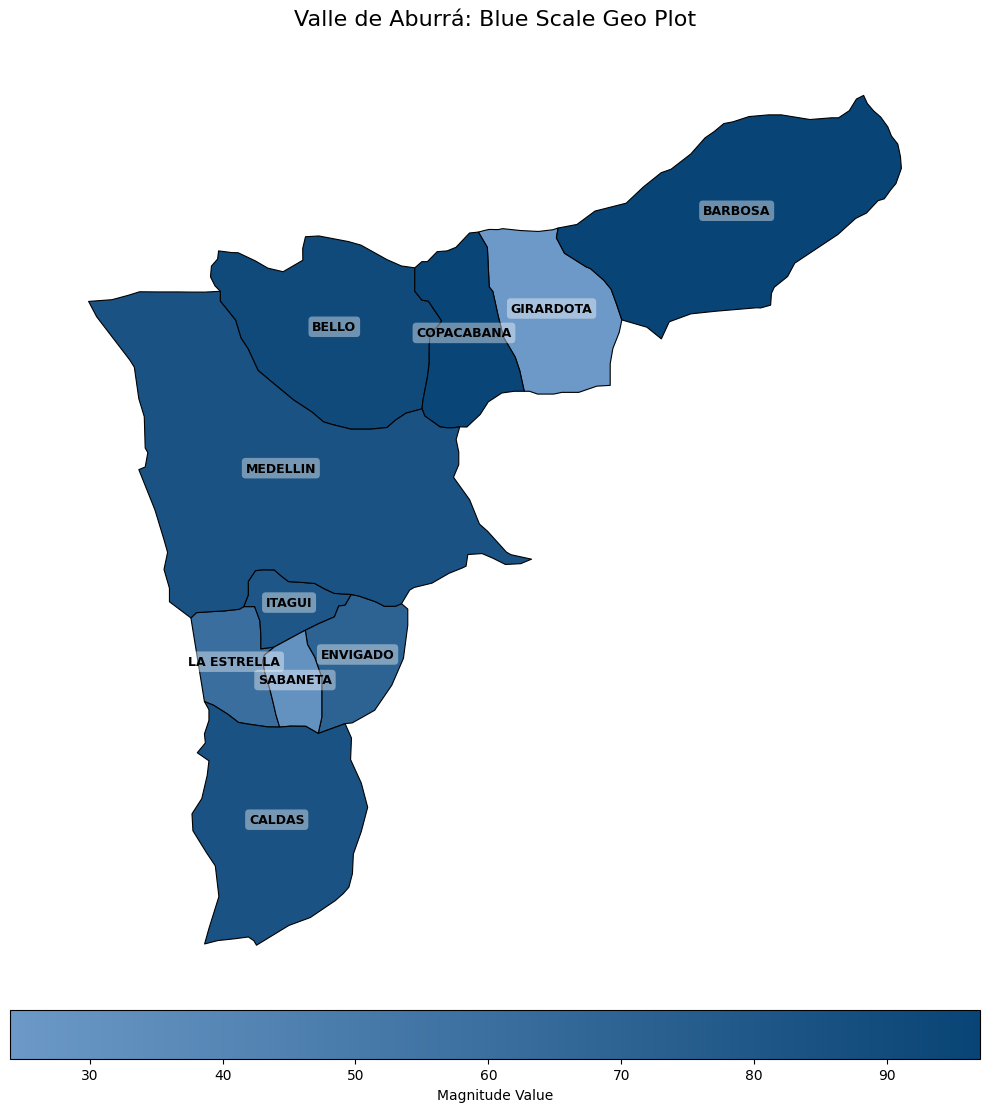

In [13]:
from matplotlib.colors import LinearSegmentedColormap

# 5. Plotting the "Blue Scale" Geo Plot
fig, ax = plt.subplots(figsize=(10, 12))

# Custom blue colormap from light (#6C99C7) to dark (#084475)
blue_cmap = LinearSegmentedColormap.from_list("custom_blue", ["#6C99C7", "#084475"])

vda_gdf.plot(
    column='magnitude',
    cmap=blue_cmap,          # Custom blue color scale
    legend=True,
    edgecolor='black',       # Visible borders
    linewidth=0.8,
    ax=ax,
    legend_kwds={'label': "Magnitude Value", 'orientation': "horizontal", 'pad': 0.02}
)

# Add Labels for each municipality
for idx, row in vda_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['nombre_mpi'], 
            fontsize=9, ha='center', color='black', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', boxstyle='round'))

ax.set_title('Valle de Aburrá: Blue Scale Geo Plot', fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('vda_blue_map.png')

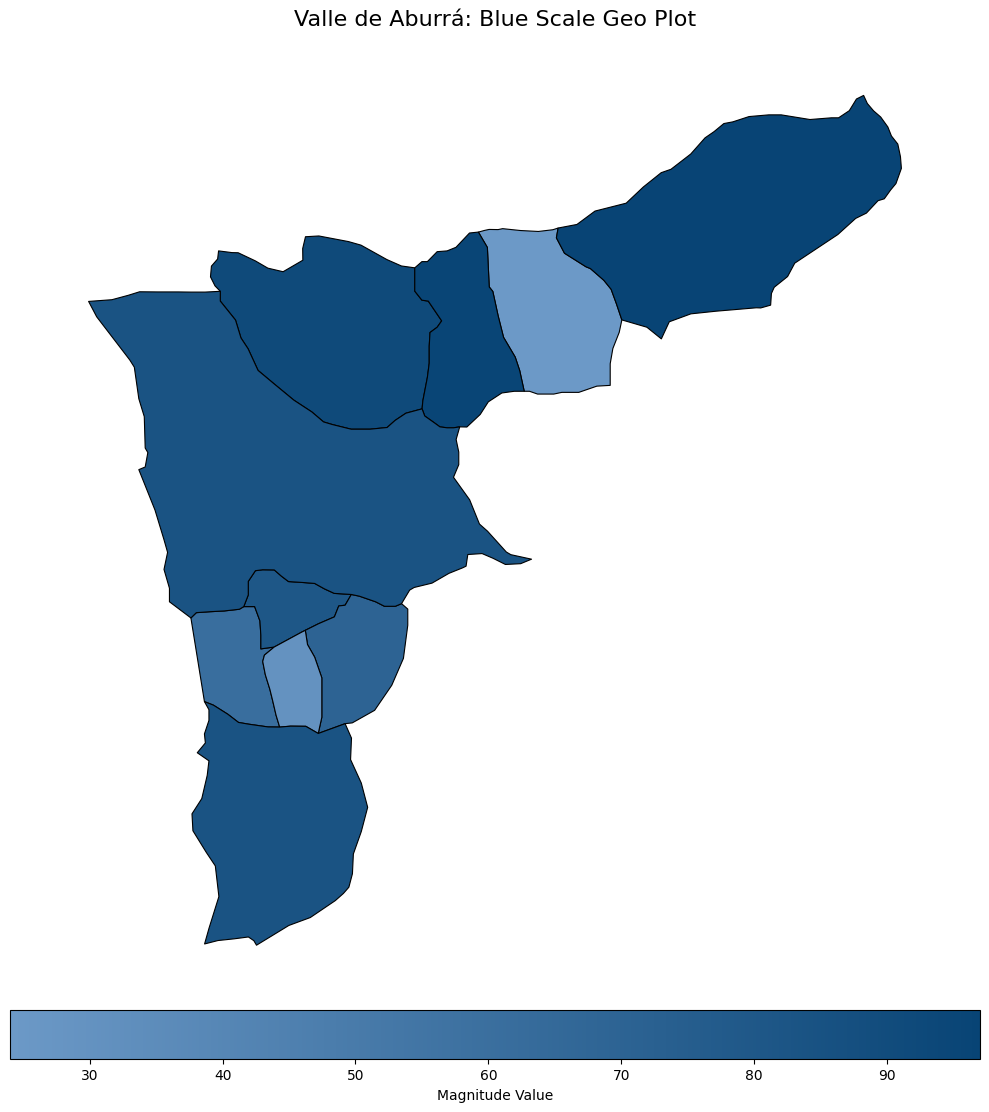

In [15]:
from matplotlib.colors import LinearSegmentedColormap

# 5. Plotting the "Blue Scale" Geo Plot
fig, ax = plt.subplots(figsize=(10, 12))

# Custom blue colormap from light (#6C99C7) to dark (#084475)
blue_cmap = LinearSegmentedColormap.from_list("custom_blue", ["#6C99C7", "#084475"])

vda_gdf.plot(
    column='magnitude',
    cmap=blue_cmap,          # Custom blue color scale
    legend=True,
    edgecolor='black',       # Visible borders
    linewidth=0.8,
    ax=ax,
    legend_kwds={'label': "Magnitude Value", 'orientation': "horizontal", 'pad': 0.02}
)



ax.set_title('Valle de Aburrá: Blue Scale Geo Plot', fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('vda_blue_map_2.png')